In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime

In [38]:
df_pi = pd.read_csv("/local/scratch/clmn1/videoNCA/measurements/temperature_pi_20260223_231658.csv")
df_phone = pd.read_csv("/local/scratch/clmn1/videoNCA/measurements/temperature_phone_20260223_203415.csv")
df_pc_back = pd.read_csv("/local/scratch/clmn1/videoNCA/measurements/temperature_pc_back_20260224_002312.csv")
df_pc_side = pd.read_csv("/local/scratch/clmn1/videoNCA/measurements/temperature_pc2_20260223_212215.csv")
df_pc_front = pd.read_csv("/local/scratch/clmn1/videoNCA/measurements/temperature_pc_20260223_183402.csv")
cold = pd.read_csv("/local/scratch/clmn1/videoNCA/measurements/temperature_cold_20260223_181348.csv")

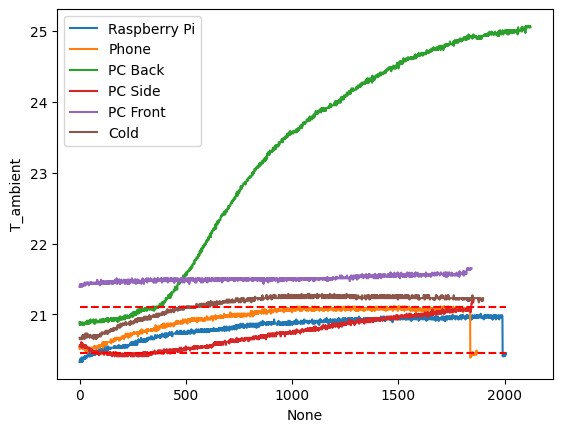

In [72]:
temp = "T_ambient"

ax = sns.lineplot(data=df_pi, x=df_pi.index, y=temp)
sns.lineplot(data=df_phone, x=df_phone.index, y=temp, ax=ax)
sns.lineplot(data=df_pc_back, x=df_pc_back.index, y=temp, ax=ax)
sns.lineplot(data=df_pc_side, x=df_pc_side.index, y=temp, ax=ax)
sns.lineplot(data=df_pc_front, x=df_pc_front.index, y=temp, ax=ax)
sns.lineplot(data=cold, x=cold.index, y=temp, ax=ax)

handles = ax.lines
ax.legend(handles, ["Raspberry Pi", "Phone", "PC Back", "PC Side", "PC Front", "Cold"])
plt.hlines(np.quantile(df_phone[temp], [0.01])[0], 0, len(df_pi), colors="red", linestyles="dashed")
plt.hlines(np.quantile(df_phone[temp], [0.99])[0], 0, len(df_pi), colors="red", linestyles="dashed")

In [73]:
q = np.quantile(df_phone[temp], [0.01, 0.99])
print(f"Temp diff between 1% and 99% quantiles: {q[1] - q[0]:.2f}°C")

Temp diff between 1% and 99% quantiles: 0.66°C


In [82]:
df_pi['time'][0], df_pi['time'][len(df_pi['time'])-1]

('20260223_231701', '20260224_000702')

In [88]:
begin = datetime.datetime.strptime(str(df_phone['time'][0]), "%Y%m%d_%H%M%S") 
end = datetime.datetime.strptime(df_phone['time'][len(df_phone['time'])-1], "%Y%m%d_%H%M%S") 

In [89]:
end - begin 

datetime.timedelta(seconds=2470)